In [1]:
import pandas as pd
import numpy as np

In [2]:
from tqdm import tqdm

In [3]:
def getTEvents(gRaw, h):
    """
    Symmetric CUSUM Filter
    Sample a bar t iff S_t >= h at which point S_t is reset
    Multiple events are not triggered by gRaw hovering around a threshold level
    It will require a full run of length h for gRaw to trigger an event
    
    Input:
        :param gRaw: the raw time series we wish to filter (gRaw)
        :param h: threshold
        
    Output:
        pd.DatatimeIndex
    """
    
    tEvents, sPos, sNeg = [], 0, 0
    diff = np.log(gRaw).diff().dropna()
    for i in tqdm(diff.index[1:]):
        try:
            pos, neg = float(sPos+diff.loc[i]), float(sNeg+diff.loc[i])
        except Exception as e:
            print(e)
            print(sPos+diff.loc[i], type(sPos+diff.loc[i]))
            print(sNeg+diff.loc[i], type(sNeg+diff.loc[i]))
            break
        sPos, sNeg=max(0., pos), min(0., neg)
        if sNeg<-h:
            sNeg=0;tEvents.append(i)
        elif sPos>h:
            sPos=0;tEvents.append(i)
    return pd.DatetimeIndex(tEvents)

In [4]:
def getDailyVol(close, span0=100):
    '''
    Calculate daily volatility estimates using exponentially weighted moving standard deviation.
    
    Input:
    - close: Pandas Series of closing prices indexed by date/time.
    - span0: Integer, span (number of days) for the EWM standard deviation (default=100).
    
    Output:
    - A Pandas Series containing daily volatility values indexed by date/time.
    '''

    # Step 1: Find the indices of the previous day's timestamps
    prev_day_indices = close.index.searchsorted(close.index - pd.Timedelta(days=1))
    prev_day_indices = prev_day_indices[prev_day_indices > 0]

    # Step 2: Map the indices to timestamps of the previous day
    prev_day_timestamps = pd.Series(
        close.index[prev_day_indices - 1], 
        index=close.index[close.shape[0] - prev_day_indices.shape[0]:]
    )

    # Step 3: Filter and align timestamps properly
    common_timestamps = prev_day_timestamps[prev_day_timestamps.isin(close.index)]
    aligned_current = common_timestamps.index.intersection(close.index)
    aligned_previous = common_timestamps.loc[aligned_current]

    # Ensure the alignment is correct
    daily_returns = pd.Series(close.loc[aligned_current].values / close.loc[aligned_previous].values - 1)

    # Step 4: Calculate exponentially weighted standard deviation of daily returns
    daily_volatility = daily_returns.ewm(span=100).std()
    daily_volatility.index = aligned_current

    return daily_volatility

In [5]:
def applyPtSlOnT1(close, events, ptSl, molecule):
    """
    Apply the triple-barrier method to determine the first barrier touched.
    
    Input:
    - close: Pandas Series of closing prices.
    - events: DataFrame with 't1' (vertical barrier) and 'trgt' (target returns).
    - ptSl: List [upper_barrier_multiplier, lower_barrier_multiplier].
    - molecule: Subset of event indices to process.
    
    Output:
    - DataFrame with timestamps of barrier touches (if any).
    """
    events_ = events.loc[molecule]  # Subset of events
    events_ = events_.fillna(close.index[-1])
    out = events_[['t1']].copy()  # Initialize output DataFrame

    for loc, t1 in events_['t1'].items():  # Fixed here
        # Extract the price path from the event start to the vertical barrier
        path_prices = close.loc[loc:t1]
        
        # Calculate the barriers
        target = events_.loc[loc, 'trgt']
        upper_barrier = close[loc] * (1 + target * ptSl[0])
        lower_barrier = close[loc] * (1 - target * ptSl[1])
        
        # Check for barrier touches
        out.loc[loc, 'pt'] = path_prices[path_prices >= upper_barrier].index.min() if (path_prices >= upper_barrier).any() else np.nan
        out.loc[loc, 'sl'] = path_prices[path_prices <= lower_barrier].index.min() if (path_prices <= lower_barrier).any() else np.nan

    return out

In [6]:
def addVerticalBarrier(close, tEvents, numDays):
    """
    Add a vertical barrier to each event.

    Parameters:
    - close: pandas Series of prices (index is datetime).
    - tEvents: pandas DatetimeIndex of timestamps for the events.
    - numDays: int, number of days after which the vertical barrier is set.

    Returns:
    - t1: pandas Series of vertical barrier timestamps for each event.
    """
    # Find the index of the next price bar at or after numDays
    t1 = close.index.searchsorted(tEvents + pd.Timedelta(days=numDays))
    t1 = t1[t1 < close.shape[0]]  # Filter out indices that exceed the series range
    t1 = pd.Series(close.index[t1], index=tEvents[:t1.shape[0]])  # Map back to event timestamps
    return t1


In [7]:
def getEvents(close, tEvents, ptSl, trgt, minRet, t1=False, side=None):
    """
    Generate events with optional meta-labeling support.

    Parameters:
    - close: pandas Series of prices (index is datetime).
    - tEvents: pandas index of event timestamps.
    - ptSl: list of floats [pt, sl] for profit-taking and stop-loss multipliers.
    - trgt: pandas Series of target returns.
    - minRet: minimum return threshold.
    - numThreads: number of threads for parallel processing.
    - t1: pandas Series of vertical barrier timestamps.
    - side: pandas Series of trade sides (1 for long, -1 for short, None for neutral).

    Returns:
    - events: DataFrame with columns ['t1', 'trgt', 'side'].
    """
    # Step 1: Filter events by target return
    trgt = trgt.loc[tEvents]
    trgt = trgt[trgt > minRet]  # Filter out events with insufficient target returns

    # Step 2: Define vertical barriers
    if t1 is False:
        t1 = pd.Series(pd.NaT, index=tEvents)  # No vertical barriers if t1 is False

    # Step 3: Adjust horizontal barriers and create the events DataFrame
    if side is None:
        _ptSl = pd.Series([ptSl[0], ptSl[0]], index=['pt', 'sl'])  # Symmetric barriers
        side_ = pd.Series(1.0, index=trgt.index)  # Default side is neutral
    else:
        _ptSl = side.loc[trgt.index] * pd.Series(ptSl[:2], index=['pt', 'sl'])  # Adjust barriers by side
        side_ = side.loc[trgt.index]  # Use the provided trade sides

    events = pd.concat({'t1': t1, 'trgt': trgt, 'side': side_}, axis=1).dropna(subset=['trgt'])

    # Step 4: Apply horizontal and vertical barriers
    df0 = applyPtSlOnT1(
        close=close,
        events=events,
        ptSl=[_ptSl['pt'], _ptSl['sl']],
        molecule=events.index
    )

    # Update t1 with the earliest barrier breach
    for ind in events.index:
        events.at[ind, 't1'] = df0.loc[ind, ['pt','sl','t1']].dropna().min()
    
    # Drop 'side' column if no meta-labeling
    if side is None:
        events = events.drop('side', axis=1)

    return events


In [30]:
def getBins(events, close):
    """
    Compute event's outcome (including side information, if provided).

    Parameters:
    - events: DataFrame with columns ['t1', 'trgt', 'side'].
    - close: pandas Series of prices (index is datetime).

    Returns:
    - DataFrame with columns:
        - 'ret': The return realized at the time of the first touched barrier.
        - 'bin': The label {1, 0}.
            - 1: Profit aligned with side (meta-labeling).
            - 0: Loss or vertical barrier reached.
    """
    # Step 1: Align prices with events
    events_ = events.dropna(subset=['t1'])  # Drop events where t1 is NaN

    px = pd.to_datetime(np.concatenate([events_.index.values, events_['t1'].values]))  # Concatenate the two arrays
    px = pd.to_datetime(pd.Series(px).unique())  # Union of start and end times
    
    # Check if any of the timestamps are timezone-aware
    if px.tz is not None:  # If any timestamps are timezone-aware
        px = px.tz_convert('UTC')  # Convert all to UTC
    else:
        px = px.tz_localize('UTC')  # If all are naive, localize to UTC

    px = close.reindex(px, method='bfill')  # Align prices with these timestamps

    # Step 2: Create output DataFrame
    out = pd.DataFrame(index=events_.index)
    out['ret'] = px.loc[events_['t1'].array].array / px.loc[events_.index] - 1  # Returns

    # Step 3: Adjust returns and labels based on 'side'
    if 'side' in events_:
        out['ret'] *= events_['side']  # Adjust return by side (direction)
        out['bin'] = np.where(out['ret'] > 0, 1, 0)  # Labels: 1 for positive, 0 for negative or vertical barrier
    else:
        out['bin'] = np.sign(out['ret'])  # Default: Labels {1, -1} based on return sign

    return out


### get data: AAPL 2024-07-01——2024-08-30

In [9]:
aapl = pd.read_csv('AAPL_2024-07-01_2024-08-30.csv',index_col=0)
aapl.index = pd.to_datetime(aapl.index)
aapl

,bid_price_1,bid_price_2,bid_price_3,bid_price_4,bid_price_5,bid_size_1,bid_size_2,bid_size_3,bid_size_4,bid_size_5,ask_price_1,ask_price_2,ask_price_3,ask_price_4,ask_price_5,ask_size_1,ask_size_2,ask_size_3,ask_size_4,ask_size_5
timestamp,,,,,,,,,,,,,,,,,,,,
2024-07-01 13:30:00+00:00,212.51,212.51,212.51,212.51,212.51,120.0,100.0,120.0,220.0,220.0,211.93,211.93,211.93,211.93,211.93,100.0,200.0,100.0,200.0,300.0
2024-07-01 13:31:00+00:00,213.07,213.07,213.07,213.07,213.07,301.0,500.0,600.0,600.0,100.0,212.35,212.35,212.36,212.36,212.36,200.0,100.0,105.0,205.0,205.0
2024-07-01 13:32:00+00:00,213.05,213.05,213.05,213.05,213.05,100.0,100.0,34.0,300.0,400.0,212.62,212.62,212.64,212.64,212.64,49.0,49.0,100.0,100.0,100.0
2024-07-01 13:33:00+00:00,213.25,213.25,213.25,213.25,213.25,100.0,100.0,52.0,110.0,210.0,212.55,212.55,212.58,212.58,212.58,3195.0,3195.0,251.0,151.0,100.0
2024-07-01 13:34:00+00:00,213.47,213.46,213.46,213.46,213.46,20.0,20.0,20.0,20.0,20.0,213.12,213.12,213.12,213.12,213.12,1.0,1.0,1.0,1.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-08-30 19:55:00+00:00,229.20,229.20,229.20,229.20,229.19,10.0,60.0,50.0,60.0,11.0,228.73,228.73,228.74,228.74,228.74,100.0,80.0,58.0,58.0,11.0
2024-08-30 19:56:00+00:00,229.00,229.00,229.00,229.00,229.00,50.0,50.0,50.0,50.0,394.0,228.93,228.93,228.94,228.94,228.94,100.0,100.0,96.0,66.0,66.0
2024-08-30 19:57:00+00:00,229.00,229.00,228.99,228.99,228.99,60.0,60.0,6384.0,6384.0,6455.0,228.98,228.98,228.98,228.98,228.98,10.0,410.0,423.0,423.0,513.0


In [10]:
close = (aapl.bid_price_1 + aapl.ask_price_1) / 2

### get volatility

In [11]:
dailyVol = getDailyVol(close)
dailyVol

timestamp
2024-07-02 13:31:00+00:00         NaN
2024-07-02 13:32:00+00:00    0.001774
2024-07-02 13:33:00+00:00    0.001353
2024-07-02 13:34:00+00:00    0.001638
2024-07-02 13:35:00+00:00    0.002672
                               ...   
2024-08-30 19:55:00+00:00    0.004185
2024-08-30 19:56:00+00:00    0.004199
2024-08-30 19:57:00+00:00    0.004225
2024-08-30 19:58:00+00:00    0.004253
2024-08-30 19:59:00+00:00    0.004278
Length: 16735, dtype: float64

In [12]:
import matplotlib.pyplot as plt

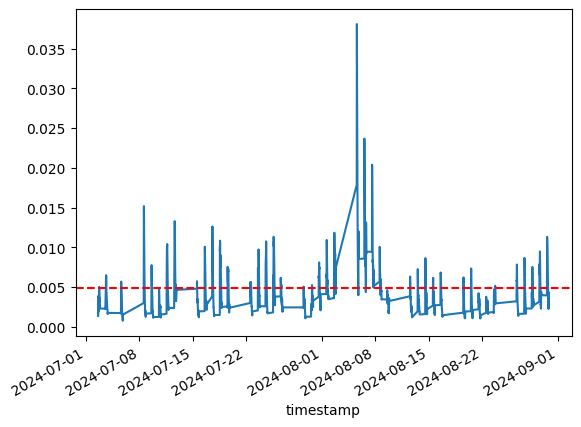

In [13]:
f, ax = plt.subplots()
dailyVol.plot(ax = ax)
ax.axhline(dailyVol.mean(),ls='--',color='red')

In [14]:
close = close.loc[dailyVol.index]

In [15]:
tEvents = getTEvents(close, h = dailyVol.mean())
tEvents

100%|██████████| 16733/16733 [00:00<00:00, 102559.32it/s]


DatetimeIndex(['2024-07-02 13:38:00+00:00', '2024-07-02 13:58:00+00:00',
               '2024-07-02 14:30:00+00:00', '2024-07-02 15:07:00+00:00',
               '2024-07-02 16:10:00+00:00', '2024-07-02 18:24:00+00:00',
               '2024-07-03 13:50:00+00:00', '2024-07-03 14:12:00+00:00',
               '2024-07-03 14:25:00+00:00', '2024-07-03 14:57:00+00:00',
               ...
               '2024-08-29 18:30:00+00:00', '2024-08-29 19:54:00+00:00',
               '2024-08-30 13:56:00+00:00', '2024-08-30 14:41:00+00:00',
               '2024-08-30 14:58:00+00:00', '2024-08-30 15:32:00+00:00',
               '2024-08-30 16:10:00+00:00', '2024-08-30 16:36:00+00:00',
               '2024-08-30 19:16:00+00:00', '2024-08-30 19:51:00+00:00'],
              dtype='datetime64[ns, UTC]', length=430, freq=None)

### add vertical barrier

In [16]:
t1 = addVerticalBarrier(close, tEvents,numDays=1)
t1

2024-07-02 13:38:00+00:00   2024-07-03 13:38:00+00:00
2024-07-02 13:58:00+00:00   2024-07-03 13:58:00+00:00
2024-07-02 14:30:00+00:00   2024-07-03 14:30:00+00:00
2024-07-02 15:07:00+00:00   2024-07-03 15:07:00+00:00
2024-07-02 16:10:00+00:00   2024-07-03 16:10:00+00:00
                                       ...           
2024-08-29 15:15:00+00:00   2024-08-30 15:15:00+00:00
2024-08-29 15:50:00+00:00   2024-08-30 15:50:00+00:00
2024-08-29 17:49:00+00:00   2024-08-30 17:49:00+00:00
2024-08-29 18:30:00+00:00   2024-08-30 18:30:00+00:00
2024-08-29 19:54:00+00:00   2024-08-30 19:54:00+00:00
Name: timestamp, Length: 422, dtype: datetime64[ns, UTC]

### get signal
random generate here, but can be replace by the signals generate by the strat-dev team

In [17]:
# trading signal
signal = pd.Series(np.random.choice([-1, 0, 1], size=len(close.index)), index=close.index)
signal.replace(0, np.nan, inplace=True)
side = signal
print(side)

timestamp
2024-07-02 13:31:00+00:00   -1.0
2024-07-02 13:32:00+00:00   -1.0
2024-07-02 13:33:00+00:00   -1.0
2024-07-02 13:34:00+00:00   -1.0
2024-07-02 13:35:00+00:00    NaN
                            ... 
2024-08-30 19:55:00+00:00    NaN
2024-08-30 19:56:00+00:00    1.0
2024-08-30 19:57:00+00:00    1.0
2024-08-30 19:58:00+00:00   -1.0
2024-08-30 19:59:00+00:00   -1.0
Length: 16735, dtype: float64


### Apply Triple-barrier
use ptSl=[0.01,0.01], minRet = 0.002, but can be changed for different requirments

In [19]:
# create target series
ptSl = [0.01,0.01]
target = dailyVol

# select minRet
minRet = 0.002
    
events = getEvents(close,tEvents, ptSl, target, minRet, t1 = t1, side=side)

In [20]:
events

,t1,trgt,side
2024-07-02 13:38:00+00:00,2024-07-03 13:38:00+00:00,0.002260,1.0
2024-07-02 13:58:00+00:00,2024-07-03 13:58:00+00:00,0.003635,NaN
2024-07-02 14:30:00+00:00,2024-07-03 14:30:00+00:00,0.003880,1.0
2024-07-02 15:07:00+00:00,2024-07-03 15:07:00+00:00,0.002655,NaN
2024-07-02 16:10:00+00:00,2024-07-03 16:10:00+00:00,0.002634,1.0
...,...,...,...
2024-08-30 15:32:00+00:00,2024-08-30 19:59:00+00:00,0.009522,1.0
2024-08-30 16:10:00+00:00,2024-08-30 19:59:00+00:00,0.006762,NaN
2024-08-30 16:36:00+00:00,2024-08-30 19:59:00+00:00,0.005801,-1.0
2024-08-30 19:16:00+00:00,2024-08-30 19:59:00+00:00,0.004316,-1.0


In [21]:
events.side.value_counts()

side
 1.0    139
-1.0    127
Name: count, dtype: int64

In [25]:
events.dropna().side

2024-07-02 13:38:00+00:00    1.0
2024-07-02 14:30:00+00:00    1.0
2024-07-02 16:10:00+00:00    1.0
2024-07-02 18:24:00+00:00    1.0
2024-07-03 13:50:00+00:00    1.0
                            ... 
2024-08-30 14:41:00+00:00    1.0
2024-08-30 14:58:00+00:00   -1.0
2024-08-30 15:32:00+00:00    1.0
2024-08-30 16:36:00+00:00   -1.0
2024-08-30 19:16:00+00:00   -1.0
Name: side, Length: 266, dtype: float64

### Apply getBins to generate labels

In [31]:
labels = getBins(events, close)
labels

,ret,bin
2024-07-02 13:38:00+00:00,0.016878,1
2024-07-02 13:58:00+00:00,NaN,0
2024-07-02 14:30:00+00:00,0.001622,1
2024-07-02 15:07:00+00:00,NaN,0
2024-07-02 16:10:00+00:00,0.007101,1
...,...,...
2024-08-30 15:32:00+00:00,0.005424,1
2024-08-30 16:10:00+00:00,NaN,0
2024-08-30 16:36:00+00:00,-0.005689,0
2024-08-30 19:16:00+00:00,-0.001050,0


In [24]:
labels.bin.value_counts()

bin
0    260
1    141
Name: count, dtype: int64